In [1]:
import os
import os.path as op
import glob
import pandas as pd
import scipy
from mne.io import read_epochs_eeglab
from lagged_autocoherence import *
import pyreadstat
import matplotlib.pyplot as plt

In [2]:
pipeline='NEARICA_behav_v3'

In [3]:
subjects = pd.read_csv('/home/bonaiuto/dcd_bursts/data/participants.tsv', sep='\t')

subject_ids = subjects['participant_id']
df, meta = pyreadstat.read_sav('/home/bonaiuto/dcd_bursts/CoMB_Dataset.sav')

In [4]:
excluded_subjects=np.array(['C34','C36'])
left_handers=np.array(['C13','C20','C23','C40','C43','C46'])

In [5]:
freq_lims = [1, 40]
lags=np.arange(0.1,4.5,.1)

In [6]:
psds={
    group: {
        hemi: [] for hemi in ['ipsi','contra']
    } for group in ['typ', 'dcd']
}
lhc={
    group: {
        hemi: [] for hemi in ['ipsi','contra']
    } for group in ['typ', 'dcd']
}
for subj_id in subject_ids:
    subject_data_dir = op.join('/home/bonaiuto/dcd_bursts/data/derivatives', pipeline, subj_id, 'processed_data')
    fname = f'{subj_id}_task.set'
    fpath = op.join(subject_data_dir, fname)
    group=df['Group'][np.where(df['SubjectID']==subj_id)[0]].values[0]
    if group==0:
        group='typ'
    else:
        group='dcd'

    mab_per=df['MABC_Percentile'][np.where(df['SubjectID']==subj_id)[0]].values[0]        
    if len(np.where(excluded_subjects==subj_id)[0]) or (group==0 and mab_per<25):
        continue
        
    if not op.exists(fpath):
        continue

    EEG = read_epochs_eeglab(fpath)
    
    fs = EEG.info['sfreq']

    data = EEG.get_data()
    data = data[:,:,(EEG.times>=0) & (EEG.times<=10)]
    n_epochs = data.shape[0]
    n_chans = data.shape[1]
    n_samps = data.shape[2]

    for cluster in ['C3','C4']:
        if cluster=='C3':
            if np.isin(subj_id,left_handers):
                hemi='ipsi'
            else:
                hemi='contra'
        else:
            if np.isin(subj_id,left_handers):
                hemi='contra'
            else:
                hemi='ipsi'

        c_chan_idx = EEG.info['ch_names'].index(cluster)

        freqs, ch_psd = scipy.signal.welch(data[:, c_chan_idx, :], fs=fs, window='hann',
                                           nperseg=int(fs), noverlap=int(fs / 2),
                                           nfft=int(fs * 2),
                                           detrend='constant',
                                           return_onesided=True, scaling='density', axis=- 1,
                                           average='mean')
        f_idx = (freqs >= freq_lims[0]) & (freqs <= freq_lims[-1])
        freqs = freqs[f_idx]
        ch_psd = np.mean(ch_psd[:, f_idx], axis=0)

        ch_lhc = lagged_hilbert_autocoherence(data[:, c_chan_idx, :], freqs, lags, fs,
                                              n_jobs=-1)
        psds[group][hemi].append(ch_psd)
        lhc[group][hemi].append(np.mean(ch_lhc,axis=0))

Extracting parameters from /home/bonaiuto/dcd_bursts/data/derivatives/NEARICA_behav_v3/C03/processed_data/C03_task.set...
Not setting metadata
28 matching events found
No baseline correction applied
0 projection items activated
Ready.


/home/bonaiuto/miniconda3/envs/new_lc/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:702: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Extracting parameters from /home/bonaiuto/dcd_bursts/data/derivatives/NEARICA_behav_v3/C04/processed_data/C04_task.set...
Not setting metadata
26 matching events found
No baseline correction applied
0 projection items activated
Ready.
Extracting parameters from /home/bonaiuto/dcd_bursts/data/derivatives/NEARICA_behav_v3/C05/processed_data/C05_task.set...
Not setting metadata
93 matching events found
No baseline correction applied
0 projection items activated
Ready.
Extracting parameters from /home/bonaiuto/dcd_bursts/data/derivatives/NEARICA_behav_v3/C06/processed_data/C06_task.set...
Not setting metadata
71 matching events found
No baseline correction applied
0 projection items activated
Ready.
Extracting parameters from /home/bonaiuto/dcd_bursts/data/derivatives/NEARICA_behav_v3/C07/processed_data/C07_task.set...
Not setting metadata
78 matching events found
No baseline correction applied
0 projection items activated
Ready.
Extracting parameters from /home/bonaiuto/dcd_bursts/data/de

/home/bonaiuto/miniconda3/envs/new_lc/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:702: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Extracting parameters from /home/bonaiuto/dcd_bursts/data/derivatives/NEARICA_behav_v3/C17/processed_data/C17_task.set...
Not setting metadata
10 matching events found
No baseline correction applied
0 projection items activated
Ready.
Extracting parameters from /home/bonaiuto/dcd_bursts/data/derivatives/NEARICA_behav_v3/C18/processed_data/C18_task.set...
Not setting metadata
54 matching events found
No baseline correction applied
0 projection items activated
Ready.
Extracting parameters from /home/bonaiuto/dcd_bursts/data/derivatives/NEARICA_behav_v3/C19/processed_data/C19_task.set...
Not setting metadata
68 matching events found
No baseline correction applied
0 projection items activated
Ready.
Extracting parameters from /home/bonaiuto/dcd_bursts/data/derivatives/NEARICA_behav_v3/C20/processed_data/C20_task.set...
Not setting metadata
35 matching events found
No baseline correction applied
0 projection items activated
Ready.
Extracting parameters from /home/bonaiuto/dcd_bursts/data/de

/home/bonaiuto/miniconda3/envs/new_lc/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:702: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Extracting parameters from /home/bonaiuto/dcd_bursts/data/derivatives/NEARICA_behav_v3/C27/processed_data/C27_task.set...
Not setting metadata
87 matching events found
No baseline correction applied
0 projection items activated
Ready.
Extracting parameters from /home/bonaiuto/dcd_bursts/data/derivatives/NEARICA_behav_v3/C28/processed_data/C28_task.set...
Not setting metadata
86 matching events found
No baseline correction applied
0 projection items activated
Ready.
Extracting parameters from /home/bonaiuto/dcd_bursts/data/derivatives/NEARICA_behav_v3/C29/processed_data/C29_task.set...
Not setting metadata
93 matching events found
No baseline correction applied
0 projection items activated
Ready.
Extracting parameters from /home/bonaiuto/dcd_bursts/data/derivatives/NEARICA_behav_v3/C30/processed_data/C30_task.set...
Not setting metadata
94 matching events found
No baseline correction applied
0 projection items activated
Ready.
Extracting parameters from /home/bonaiuto/dcd_bursts/data/de

/home/bonaiuto/miniconda3/envs/new_lc/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:702: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Extracting parameters from /home/bonaiuto/dcd_bursts/data/derivatives/NEARICA_behav_v3/C50/processed_data/C50_task.set...
Not setting metadata
57 matching events found
No baseline correction applied
0 projection items activated
Ready.
Extracting parameters from /home/bonaiuto/dcd_bursts/data/derivatives/NEARICA_behav_v3/C51/processed_data/C51_task.set...
Not setting metadata
82 matching events found
No baseline correction applied
0 projection items activated
Ready.
Extracting parameters from /home/bonaiuto/dcd_bursts/data/derivatives/NEARICA_behav_v3/C52/processed_data/C52_task.set...
Not setting metadata
91 matching events found
No baseline correction applied
0 projection items activated
Ready.
Extracting parameters from /home/bonaiuto/dcd_bursts/data/derivatives/NEARICA_behav_v3/C53/processed_data/C53_task.set...
Not setting metadata
79 matching events found
No baseline correction applied
0 projection items activated
Ready.
Extracting parameters from /home/bonaiuto/dcd_bursts/data/de

In [7]:
for group in lhc:
    for hemi in lhc[group]:
        lhc[group][hemi]=np.array(lhc[group][hemi])

In [8]:
output_file = op.join('/home/bonaiuto/dcd_bursts/data/derivatives', pipeline, f'lhc.npz')
np.savez(
    output_file,
    lhc=lhc,
    lags=lags,
    freqs=freqs,
    psds=psds
)

In [23]:
l_idx=(lags>=1)
f_idx=(freqs<=50)

In [24]:
lags

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2, 1.3,
       1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5, 2.6,
       2.7, 2.8, 2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9,
       4. , 4.1, 4.2, 4.3, 4.4])

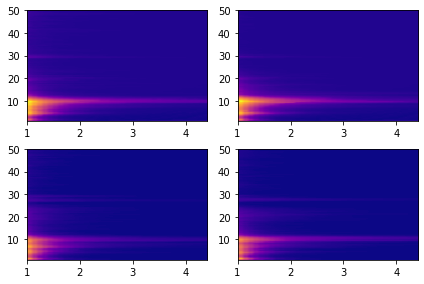

In [28]:
typ_contra=np.mean(lhc['typ']['contra'][:,f_idx][:,:,l_idx],axis=0)
typ_ipsi=np.mean(lhc['typ']['ipsi'][:,f_idx][:,:,l_idx],axis=0)
dcd_contra=np.mean(lhc['dcd']['contra'][:,f_idx][:,:,l_idx],axis=0)
dcd_ipsi=np.mean(lhc['dcd']['ipsi'][:,f_idx][:,:,l_idx],axis=0)
max_lhc=np.max(np.vstack([
    typ_contra[:],
    typ_ipsi[:],
    dcd_contra[:],
    dcd_ipsi[:]
]))

plt.subplot(2,2,1)
plt.imshow(
    typ_contra,
    origin='lower',
    aspect='auto',
    extent=[lags[l_idx][0], lags[l_idx][-1], freqs[f_idx][0], freqs[f_idx][-1]],
    vmin=0,
    vmax=max_lhc,
    cmap='plasma'
)
plt.subplot(2,2,2)
plt.imshow(
    typ_ipsi,
    origin='lower',
    aspect='auto',
    extent=[lags[l_idx][0], lags[l_idx][-1], freqs[f_idx][0], freqs[f_idx][-1]],
    vmin=0,
    vmax=max_lhc,
    cmap='plasma'
)
plt.subplot(2,2,3)
plt.imshow(
    dcd_contra,
    origin='lower',
    aspect='auto',
    extent=[lags[l_idx][0], lags[l_idx][-1], freqs[f_idx][0], freqs[f_idx][-1]],
    vmin=0,
    vmax=max_lhc,
    cmap='plasma'
)
plt.subplot(2,2,4)
plt.imshow(
    dcd_ipsi,
    origin='lower',
    aspect='auto',
    extent=[lags[l_idx][0], lags[l_idx][-1], freqs[f_idx][0], freqs[f_idx][-1]],
    vmin=0,
    vmax=max_lhc,
    cmap='plasma'
)
plt.tight_layout()

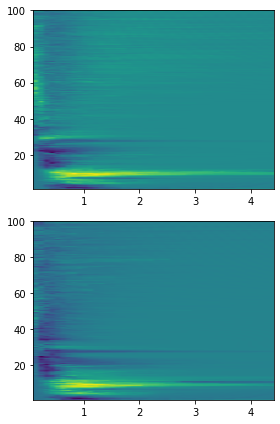

In [30]:
plt.figure(figsize=(4,6))
plt.subplot(2,1,1)
plt.imshow(
    np.mean(lhc['typ']['contra'],axis=0)-np.mean(lhc['dcd']['contra'],axis=0),
    origin='lower',
    aspect='auto',
    extent=[lags[0], lags[-1], freqs[0], freqs[-1]]
)
plt.subplot(2,1,2)
plt.imshow(
    np.mean(lhc['typ']['ipsi'],axis=0)-np.mean(lhc['dcd']['ipsi'],axis=0),
    origin='lower',
    aspect='auto',
    extent=[lags[0], lags[-1], freqs[0], freqs[-1]]
)

plt.tight_layout()

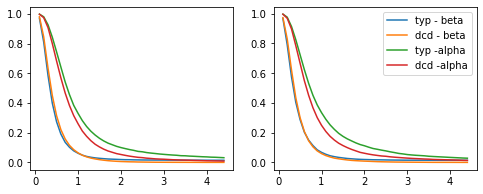

In [31]:
alpha_lims=[6.75, 12.75]
beta_lims=[14.25, 23.75]
alpha_idx=(freqs>=alpha_lims[0]) & (freqs<=alpha_lims[1])
beta_idx=(freqs>=beta_lims[0]) & (freqs<=beta_lims[1])
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.plot(lags,np.mean(np.mean(lhc['typ']['contra'][:,beta_idx,:],axis=1),axis=0),label='typ - beta')
plt.plot(lags,np.mean(np.mean(lhc['dcd']['contra'][:,beta_idx,:],axis=1),axis=0),label='dcd - beta')
plt.plot(lags,np.mean(np.mean(lhc['typ']['contra'][:,alpha_idx,:],axis=1),axis=0),label='typ - alpha')
plt.plot(lags,np.mean(np.mean(lhc['dcd']['contra'][:,alpha_idx,:],axis=1),axis=0),label='dcd - alpha')
plt.subplot(1,2,2)
plt.plot(lags,np.mean(np.mean(lhc['typ']['ipsi'][:,beta_idx,:],axis=1),axis=0),label='typ - beta')
plt.plot(lags,np.mean(np.mean(lhc['dcd']['ipsi'][:,beta_idx,:],axis=1),axis=0),label='dcd - beta')
plt.plot(lags,np.mean(np.mean(lhc['typ']['ipsi'][:,alpha_idx,:],axis=1),axis=0),label='typ -alpha')
plt.plot(lags,np.mean(np.mean(lhc['dcd']['ipsi'][:,alpha_idx,:],axis=1),axis=0),label='dcd -alpha')
plt.legend()

In [11]:
(1/((23.75-17.25)/2+17.25)*3)*2

0.29268292682926833